# Spatial Proteomics analysis (MACSima)
In this series of notebooks, we will analyze a Miltenyi [MACSima](https://www.miltenyibiotec.com/DE-en/products/macs-imaging-and-spatial-biology/macsima-platform.html?query=:relevance:allCategoriesOR:10000717) dataset using the [Harpy](https://harpy.readthedocs.io/en/latest/) package. We will explore QC, segmentation, feature extraction, interactive object classification, and segmentation-free approaches such as tesselation and pixel-clustering.

When you make use of Harpy for analysis of spatial proteomics data, please cite [Rombaut et al. (2026)](https://academic.oup.com/bioinformatics/article/42/3/btag122/8519620?login=false).

Below, we will work on a 3000 x 3000 pixel subset of the MACSima dataset.

## Import packages

In [1]:
import os
import harpy as hp
import spatialdata_plot
import dask.array as da
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import scanpy as sc
from spatialdata.models import TableModel

_ = spatialdata_plot

## 1. Read SpatialData
Harpy provides a convenient MACSima reader, [`hp.io.macsima`](https://harpy.readthedocs.io/en/latest/generated/harpy.io.macsima.html#harpy.io.macsima), which reads the data preprocessed by [MACS iQ View](https://www.miltenyibiotec.com/UN-en/products/macs-iq-view-3d-large-volume-software.html) and can be used to construct a `SpatialData` object directly from the preprocessed dataset.

However, for the purposes of this training, we already completed this step and cropped the dataset to a 3000 x 3000 region of interest. We can fetch it from our registry using the code below.

In [2]:
import sys
import tempfile
from pathlib import Path

from spatialdata import read_zarr

if sys.platform == "win32":
    # Force short paths to avoid running into Windows limitation with path > 260 characters.
    temp_dir = "c:\\tmp"
    course_data_cache_path = "c:\\hp_cache"
else:
    temp_dir = None  # use OS default
    course_data_cache_path = None  # use OS default

tmp = tempfile.TemporaryDirectory(dir=temp_dir, prefix="macsima_")
output_dir = Path(tmp.name)

sdata = hp.datasets.macsima_colorectal_carcinoma_course(
    checkpoint="checkpoint_1",
    path=course_data_cache_path,
)

sdata.write(output_dir / "sdata.zarr", overwrite=True)

sdata = read_zarr(sdata.path)

WARNING  Module 'bioio' is not installed. Install it with `pip install bioio` to use `harpy.io.macsima`.           
WARNING  Module 'bioio-ome-tiff' is not installed. Install it with `pip install bioio-ome-tiff` to use             
         `harpy.io.macsima`.                                                                                       


/Users/arne.defauw/VIB/targeted_transcriptomics_training/.venv/lib/python3.12/site-packages/rasterio/features.py:148: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  yield from _shapes(source, mask, connectivity, transform)
/Users/arne.defauw/VIB/targeted_transcriptomics_training/.venv/lib/python3.12/site-packages/rasterio/features.py:148: NotGeoreferencedWarning: The given matrix is equal to Affine.identity or its flipped counterpart. GDAL may ignore this matrix and save no geotransform without raising an error. This behavior is somewhat driver-specific.
  yield from _shapes(source, mask, connectivity, transform)


In [3]:
# Let's inspect the SpatialData object
sdata

SpatialData object, with associated Zarr store: /private/var/folders/sz/t3tgg4fs4tz9btm0fbqg_tzc0000gn/T/macsima_iocl6m6t/sdata.zarr
└── Images
      └── 'REAscreen_IO_CRC': DataTree[cyx] (62, 3000, 3000), (62, 1500, 1500), (62, 750, 750), (62, 375, 375), (62, 187, 187)
with coordinate systems:
    ▸ 'global_1', with elements:
        REAscreen_IO_CRC (Images)
    ▸ 'global_1_micron', with elements:
        REAscreen_IO_CRC (Images)

In [4]:
# To download the raw image data (e.g. to try the MACSima reader or read the images in Qupath for QC or annotation (see 2.2)), we can fetch them from the registry.
# Note that this is a large download (~15 GB) and may take some time.

# from harpy.datasets.registry import get_registry
# registry = get_registry(path=course_data_cache_path)
# path_CRC_images = registry.fetch("proteomics/macsima/REAscreen_IO_CRC/REAscreen_IO_CRC_fixed.zip")

### 1.1 Customize channel names
In case of proteomics (or other types of multi-channel imaging data), we often need to be able to customize the channel names. For example, below, we can see that the MACSima reader function automatically assigned clunky names and we may want to simplify these to the relevant biological information.

In [5]:
# Check channel names
original_channel_names = hp.im.get_dataarray(sdata, element_name="REAscreen_IO_CRC").c.data
original_channel_names[:5]

array(['0_DAPI_1_DAPI', '1_CD279_1_CD279__REA1165',
       '1_Bcl 2_1_Bcl 2__REA872', '1_CD209_1_CD209__REAL690',
       '2_FoxP3_1_FoxP3__REA1253'], dtype='<U51')

In [6]:
# First, we define a custom function to clean up the channel names. In this case, we want to extract the part of the channel name that is between the first and second underscores.
import re


def simplify_channel_name(channel: str) -> str:
    match = re.match(r"^\d+_(.*?)_\d+_", channel)
    if match is None:
        return channel
    return match.group(1).replace(" ", "_")


# Apply the function to all channel names to create a new list of channel names
new_channel_names = [simplify_channel_name(channel_name) for channel_name in original_channel_names]

# Using .set_channel_names(), we can update the channel names in the SpatialData object
sdata.set_channel_names(element_name="REAscreen_IO_CRC", channel_names=new_channel_names, write=True)

In [7]:
# Let's check the updated channel names
hp.im.get_dataarray(sdata, element_name="REAscreen_IO_CRC").c.data

array(['DAPI', 'CD279', 'Bcl_2', 'CD209', 'FoxP3', 'CD8a', 'CD44', 'p53',
       'CD138', 'CD45', 'CD15', 'Collagen_I', 'CD274', 'Cytokeratin_7',
       'CD223', 'PCNA', 'CD163', 'CD11b', 'CD56', 'CD45RB', 'CD14',
       'CD107a', 'CD4', 'Cytokeratin_14', 'Ki_67', 'CD107b', 'CD31',
       'CD45RA', 'CD38', 'CD66', 'Cleaved_PARP1', 'Mast_Cell_Tryptase',
       'CD66b', 'Podoplanin', 'CD20_Cytoplasmic', 'CD134', 'CD16', 'CD1c',
       'CD68', 'Actin', 'CD79a', 'Cytokeratin_20', 'CD45RO', 'CD11c',
       'Vimentin', 'CD3', 'CD324', 'HLA_ABC', 'CD57', 'Cytokeratin_5',
       'CD204', 'Cytokeratin_8', 'MART_1', 'Cytokeratin_19',
       'Melanocyte_PMEL', 'Cytokeratin', 'HLA_DR', 'beta_Catenin',
       'beta_Actin', 'CD326', 'Cytokeratin_HMW', 'Calponin'], dtype='<U18')

## 2 QC
Next, we need to QC all channels and determine which ones succeeded and which channels should be excluded from the analysis. We also need to determine whether there are technical artifacts in the images (e.g. regions that are out-of-focus regions, contains stitching or registration errors, tissue folds, etc.) that we want to avoid during the analysis. 

Generally, the best approach seems to do this manually by using interactive visualization software such as MACS IQ View, Qupath or Napari-harpy. To do this well, you would need biological and technical insights in the expected staining patterns of each marker.

### 2.1 Napari-harpy

In [8]:
# We can inspect the quality of all channels in Napari
from napari_harpy import Interactive

Interactive(sdata, widgets="viewer")

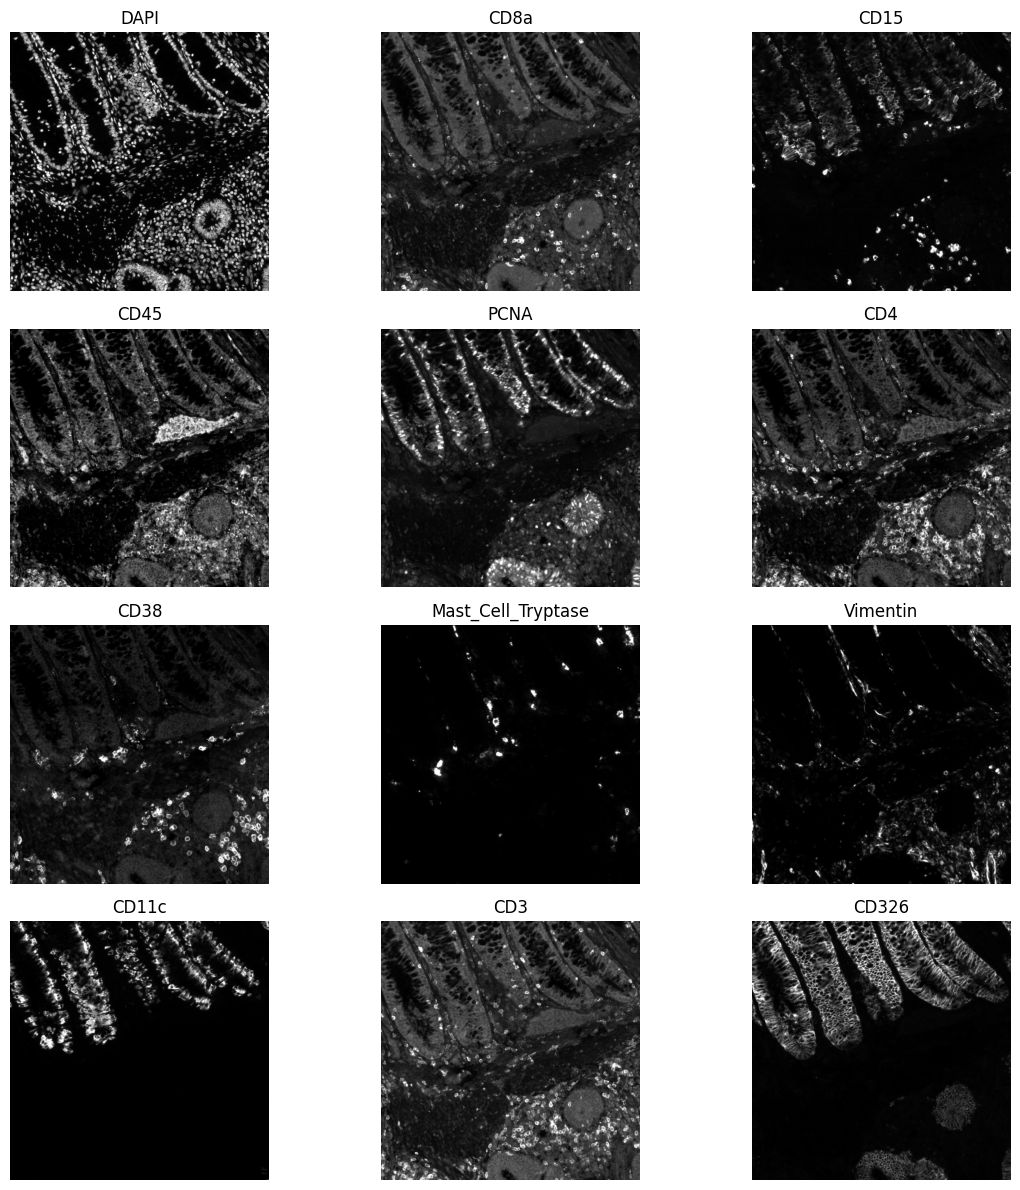

In [9]:
# We can also create static visualizations of the channels using Harpy's plotting functions.
# Here, we will visualize the first 12 channels in a 4x3 grid.
from matplotlib.colors import Normalize

fig, axes = plt.subplots(4, 3, figsize=(12, 12))
_image_name = "REAscreen_IO_CRC"
to_coordinate_system = "global_1"

_channels_to_visualize = [
    "DAPI",
    "CD8a",
    "CD15",
    "CD45",
    "PCNA",
    "CD4",
    "CD38",
    "Mast_Cell_Tryptase",
    "Vimentin",
    "CD11c",
    "CD3",
    "CD326",
]

se = hp.im.get_dataarray(sdata, element_name=_image_name)
channels = se.c.data

for _ax, _channel in zip(axes.flatten(), _channels_to_visualize, strict=False):
    # Define normalization parameters for visualization (this does not change the underlying image)
    _channel_idx = np.where(channels == _channel)[0].item()
    vmax = da.percentile(se.data[_channel_idx].flatten(), q=99).compute()
    norm = Normalize(vmax=vmax, clip=False)

    render_images_kwargs = {
        "cmap": "gray",
        "norm": norm,
        "scale": "scale1",
    }  # pass scale for faster plotting, but at lower resolution
    show_kwargs = {"title": _channel, "colorbar": False}

    _ax = hp.pl.plot_sdata(
        sdata,
        image_name=_image_name,
        channel=_channel,
        to_coordinate_system=to_coordinate_system,
        render_images_kwargs=render_images_kwargs,
        show_kwargs=show_kwargs,
        ax=_ax,
    )

    _ax.axis("off")  # frameless figure

plt.tight_layout()
plt.show()

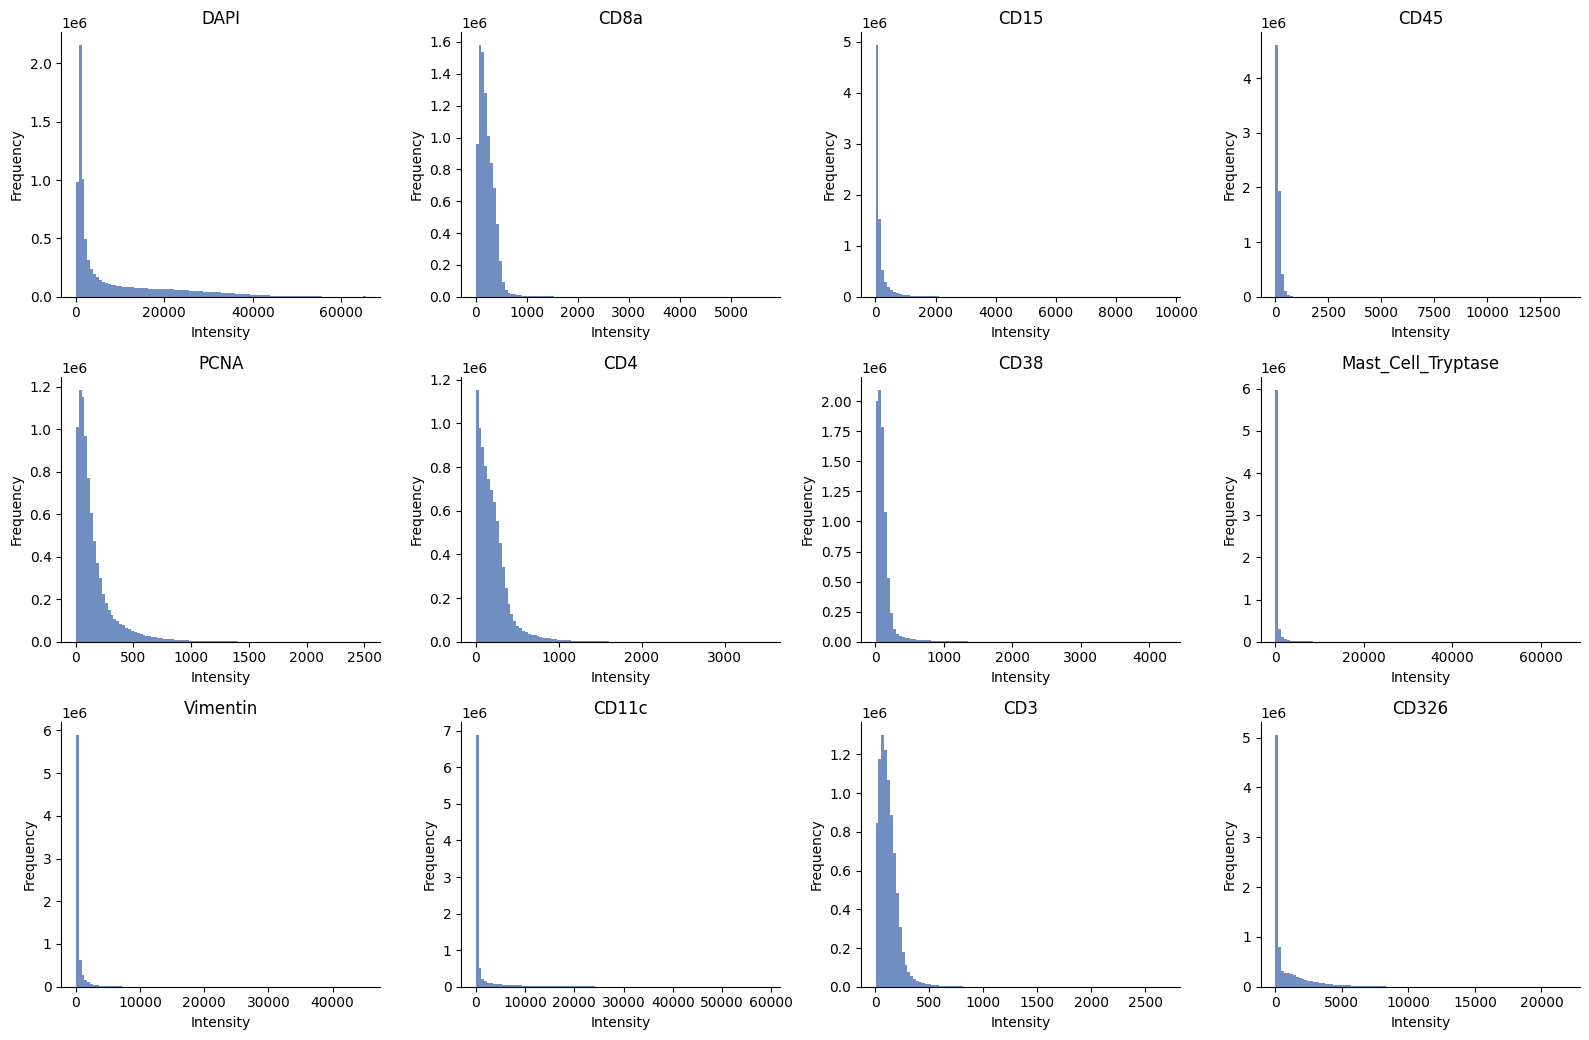

In [10]:
# We can also visualize the distribution of pixel intensities for each channel as a histogram.
ax = hp.qc.image_histogram(
    sdata,
    image_name="REAscreen_IO_CRC",
    channel=_channels_to_visualize,
    ncols=4,
    bins=100,
)

### 2.2 Qupath
Qupath is open source software for bioimage analysis. It has some really nice tools for annotating regions of interest and artifacts in images. We will use these for our dataset and add the results to the SpatialData object.

1. Download the raw image data from the registry using the code above.
2. If necessary, install Qupath using this [link](https://qupath.github.io/).
2. Open Qupath and click `Create project` in the top left corner.
3. Create a new empty folder for the project and click `Select Folder`.
4. You would normally add images to a project by going to `Add images` and providing the image paths. However, this would result in the images being added separately, and we would prefer a merged image containing all channels. To do this, we will use the `read_multichannel_qupath.groovy` script. To run it, go to `Automate`, `Script Editor`, `File`, `Open`, and select the script. In the Qupath script editor, change the folderPath argument to the folder containing the MACSima images and click `Run`. This should add all images to the project as a single image.
5. Explore the image by going to `Brightness & contrast`, select the channels you want to visualize and adjust the settings to improve the visualization.

#### 2.2.1 QC image channels
Using Qupath, we have created a python list of succesful channels and a list for failed channels. Since we're not experts in this tissue, we've aimed for removing the channels with obvious flaws (note that this is subjective and very dependent on how well you know the underlying biology and expected staining patterns for the biomarkers).

In [11]:
successful_channels = [
    "DAPI",
    "Bcl_2",  # Clearly contains acquisition bleaching artifacts, but we can annotate these regions to remove them
    "CD8a",
    "FoxP3",
    "CD138",
    "CD15",
    "CD45",
    "Collagen_I",
    "CD274",
    "PCNA",
    "CD163",
    "CD56",
    "CD11b",
    "CD45RB",
    "CD14",
    "CD107a",
    "Ki_67",
    "CD4",
    "CD107b",
    "CD31",
    "CD38",
    "CD66b",
    "Cleaved_PARP1",
    "Mast_Cell_Tryptase",
    "CD20_Cytoplasmic",
    "Podoplanin",
    "CD16",
    "CD1c",
    "Actin",
    "CD68",
    "Cytokeratin_20",
    "CD79a",
    "CD45RO",
    "Vimentin",
    "CD11c",
    "CD3",
    "CD324",
    "HLA_ABC",
    "CD57",
    "CD204",
    "MART_1",
    "Melanocyte_PMEL",
    "Cytokeratin_19",
    "Cytokeratin",
    "HLA_DR",
    "beta_Catenin",
    "beta_Actin",
    "CD326",
    "Calponin",
]

failed_channels = [
    "CD209",  # Uneven illumination
    "CD279",  # Uneven illumination
    "CD44",  # Uneven illumination
    "p53",  # Uneven illumination
    "Cytokeratin_7",  # Uneven illumination
    "CD223",  # Very bright (saturating) artifact
    "Cytokeratin_14",  # Uneven illumination
    "CD45RA",  # Uneven illumination
    "CD66",  # Very bright (saturating) artifact
    "CD134",  # Uneven illumination
    "Cytokeratin_5",  # Uneven illumination
    "Cytokeratin_8",  # Uneven illumination
    "Cytokeratin_HMW",  # Uneven illumination
]

#### 2.2.2 Annotate artifacts

1. Open the `Bcl 2 (C3)` channel and annotate the acquisition bleaching regions. Since these are straight lines, you can use the rectangle annotation to annotate all the segments and subsequently merge the annotation by going to `Objects`, `Annotations...`, `Merge selected`. Rename the merged annotation to `acquisition_bleaching` by right-clicking on the annotation in the `Annotations` tab and going to `Set properties`.

2. Open the `DAPI (C1)` channel. In other datasets, we may find some out-of-focus regions, tissue-folds, etc that we could annotate. In this dataset, there is a small very bright region at the top right of the tissue. Annotate it using either the polygon annotation tool or the magic brush, merge any annotation objects you create and rename the merged object `bright_artifact`.

3. Export the annotations. Select all artifact annotations and go to `File`, `Export objects as GeoJSON` and set to `Selected objects` and `Compression` to None. Click `OK` and set the file name to `artifacts.geojson`.

#### 2.2.3 Annotate ROIs
Now, pick a region that looks of interest to you, annotate it and label it `ROI`. Select it and export the GeoJSON as `ROI.geojson.`

#### 2.2.4 Add annotations to sdata

In [13]:
from spatialdata.transformations import Translation, Scale, Sequence

paths_to_GeoJSONs = {
    "artifacts": "annotations/artifacts.geojson",  # FIXME: registry.fetch()
    "ROI": "annotations/ROI.geojson",  # FIXME: registry.fetch()
}

transformations = {
    "global_1": Translation([-7000, -2000], axes=("x", "y")),
    "global_1_micron": Sequence([Translation([-7000, -2000], axes=("x", "y")), Scale([0.17, 0.17], axes=("x", "y"))]),
}  # For this training, we need to translate the annotations since we are working on a crop of the data of which the origin was reset to (0,0).

for name, path in paths_to_GeoJSONs.items():
    gdf_regions = gpd.read_file(path)
    sdata = hp.sh.add_shapes(
        sdata, input=gdf_regions, output_shapes_name=name, overwrite=True, transformations=transformations
    )

sdata

SpatialData object, with associated Zarr store: /private/var/folders/sz/t3tgg4fs4tz9btm0fbqg_tzc0000gn/T/macsima_iocl6m6t/sdata.zarr
├── Images
│     └── 'REAscreen_IO_CRC': DataTree[cyx] (62, 3000, 3000), (62, 1500, 1500), (62, 750, 750), (62, 375, 375), (62, 187, 187)
└── Shapes
      ├── 'ROI': GeoDataFrame shape: (1, 5) (2D shapes)
      └── 'artifacts': GeoDataFrame shape: (2, 5) (2D shapes)
with coordinate systems:
    ▸ 'global_1', with elements:
        REAscreen_IO_CRC (Images), ROI (Shapes), artifacts (Shapes)
    ▸ 'global_1_micron', with elements:
        REAscreen_IO_CRC (Images), ROI (Shapes), artifacts (Shapes)

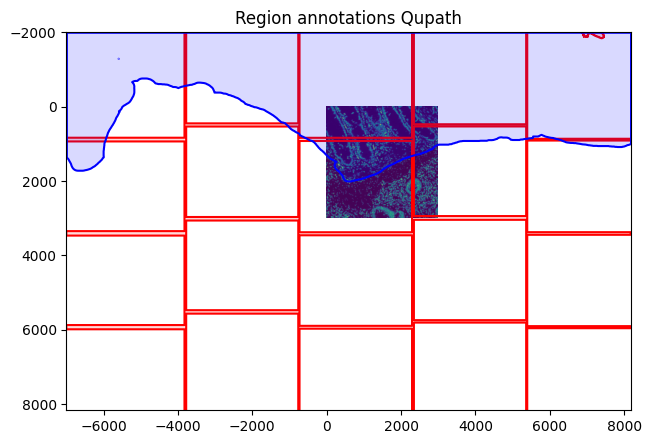

In [14]:
# Let's check whether the region annotations were added correctly
sdata.pl.render_images(element="REAscreen_IO_CRC", channel="DAPI").pl.render_shapes(
    element="artifacts", color="red", fill_alpha=0.15, outline_alpha=1, outline_color="red"
).pl.render_shapes(
    element="ROI",
    color="blue",
    fill_alpha=0.15,
    outline_alpha=1,
    outline_color="blue",
).pl.show(
    coordinate_systems="global_1",
    title="Region annotations Qupath",
    colorbar=False,
)

## 3. Segmentation
In this notebook, we will demonstrate how to use InstanSeg for nucleus and cell segmentation. However, in practice, it might be useful to try different models and determine which one performs the best for your sample.

### 3.1 Preprocess segmentation channels

In [15]:
# Create subset of segmentation channels
segmentation_channels = [
    "DAPI",
    "CD8a",
    "CD15",
    "CD45",
    "PCNA",
    "CD4",
    "CD38",
    "Mast_Cell_Tryptase",
    "Vimentin",
    "CD11c",
    "CD3",
    "HLA_ABC",
    "CD326",
]

se = hp.im.get_dataarray(sdata, element_name="REAscreen_IO_CRC")
arr = se.sel(c=segmentation_channels).data
arr

dask.array<getitem, shape=(13, 3000, 3000), dtype=uint16, chunksize=(1, 1024, 1024), chunktype=numpy.ndarray>

In [16]:
# Add as image layer to SpatialData object
from spatialdata.transformations import get_transformation

sdata = hp.im.add_image(
    sdata,
    arr=arr,
    output_image_name="REAscreen_IO_CRC_segmentation_channels",
    c_coords=segmentation_channels,
    transformations=get_transformation(sdata["REAscreen_IO_CRC"], get_all=True),
    scale_factors=[2, 2, 2, 2],
    overwrite=True,
)

2026-06-10 14:19:13.769 | INFO     | harpy.image._manager:add_element:47 - Writing results to element 'REAscreen_IO_CRC_segmentation_channels'


In [17]:
# Normalize images based on lower and upper percentile (This is commented out since Instanseg does this internally)
# sdata = hp.im.normalize(
#    sdata,
#    image_name="REAscreen_IO_CRC_segmentation_channels",
#    output_image_name="REAscreen_IO_CRC_segmentation_channels_norm",
#    q_min=20.0,
#    q_max=99.9,
#    overwrite=True,
# )

# Perform min max filtering
sdata = hp.im.min_max_filtering(
    sdata,
    image_name="REAscreen_IO_CRC_segmentation_channels",
    output_image_name="REAscreen_IO_CRC_segmentation_channels_minmax",
    size_min_max_filter=55,
    overwrite=True,
)

# Perform contrast enhancement using CLAHE
sdata = hp.im.enhance_contrast(
    sdata,
    image_name="REAscreen_IO_CRC_segmentation_channels_minmax",
    output_image_name="REAscreen_IO_CRC_segmentation_channels_clahe",
    contrast_clip=3.5,
    chunks=(1, 2048, 2048),
    overwrite=True,
)

2026-06-10 14:19:14.596 | INFO     | harpy.image._map:_precondition:339 - 'combine_z' is False, but not all 'z-slices' spefified in 'fn_kwargs'/'func' ({'size_min_max_filter': 55}/<function min_max_filtering.<locals>._apply_min_max_filter at 0x14c45eb60>). Specifying z-slices ([0]).
2026-06-10 14:19:14.597 | INFO     | harpy.image._map:_precondition:345 - 'combine_c' is False, but not all channels spefified in 'fn_kwargs'/'func' ({np.int64(0): {'size_min_max_filter': 55}}/{np.int64(0): <function min_max_filtering.<locals>._apply_min_max_filter at 0x14c45eb60>}). Specifying channels (['DAPI' 'CD8a' 'CD15' 'CD45' 'PCNA' 'CD4' 'CD38' 'Mast_Cell_Tryptase'
 'Vimentin' 'CD11c' 'CD3' 'HLA_ABC' 'CD326']).
2026-06-10 14:19:14.966 | INFO     | harpy.image._manager:add_element:47 - Writing results to element 'REAscreen_IO_CRC_segmentation_channels_minmax'
2026-06-10 14:19:19.928 | INFO     | harpy.image._map:_precondition:339 - 'combine_z' is False, but not all 'z-slices' spefified in 'fn_kwargs'

In [18]:
# Let's inspect the images
from napari_harpy import Interactive

Interactive(sdata)

### 3.2 Nucleus segmentation

In [19]:
from instanseg import InstanSeg

# Call the function to download and extract the models
instanseg_fluorescence = InstanSeg("fluorescence_nuclei_and_cells", verbosity=1, device="cpu")

# or load the model from a path
path_model = os.path.join(
    os.environ.get("INSTANSEG_BIOIMAGEIO_PATH"),
    "fluorescence_nuclei_and_cells/0.1.1/instanseg.pt",
)

Model fluorescence_nuclei_and_cells version 0.1.1 already downloaded in /Users/arne.defauw/VIB/targeted_transcriptomics_training/.venv/lib/python3.12/site-packages/instanseg/utils/../bioimageio_models/, loading


In [20]:
# Nucleus segmentation with InstanSeg
import torch
from dask.distributed import LocalCluster, Client

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Using device: {device}.")

cluster = LocalCluster(
    n_workers=8
    if device == "cpu"
    else 1,  # if cuda device available, it is better to increase chunk size to maximal value that fits on the gpu, and set n_workers to 1.
    threads_per_worker=1,
    memory_limit="32GB",
)

client = Client(cluster)

print(client.dashboard_link)

print("Segmenting nuclei:")

sdata = hp.im.segment(
    sdata,
    image_name="REAscreen_IO_CRC_segmentation_channels_clahe",
    output_labels_name=["labels_nuclei_instanseg"],
    output_shapes_name=["shapes_nuclei_instanseg"],
    labels_layer_align=None,
    model=hp.im.instanseg_callable,
    # parameters passed to hp.im.instanseg_callable
    output="nuclei",
    device=device,
    instanseg_model=path_model,
    pixel_size=0.17,
    overwrite=True,
)

client.close()

Using device: mps.
http://127.0.0.1:8787/status
Segmenting nuclei:


2026-06-10 14:19:36.439 | INFO     | harpy.image.segmentation._segmentation:_precondition:434 - Provided array is chunked in 'z' and/or 'c' dimension. Will rechunk in 'z' and/or 'c' dimension.
/Users/arne.defauw/VIB/targeted_transcriptomics_training/.venv/lib/python3.12/site-packages/harpy/image/segmentation/segmentation_models/_instanseg.py:78: UserWarning: 'torch.load' received a zip file that looks like a TorchScript archive dispatching to 'torch.jit.load' (call 'torch.jit.load' directly to silence this warning)
  instanseg_model = torch.load(instanseg_model, weights_only=False)
/Users/arne.defauw/VIB/targeted_transcriptomics_training/.venv/lib/python3.12/site-packages/instanseg/inference_class.py:473: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with torch.amp.autocast('cuda'):
/Users/arne.defauw/VIB/targeted_transcriptomics_training/.venv/lib/python3.12/site-packages/torch/nn/modules/module.py:1789: UserWarning: Sparse CSR tensor support is in

,labels_name,total_instances,total_area_μm²,covered_area_μm²,covered_area_percentage
0,labels_nuclei_instanseg,3260,260100.0,87123.5006,33.496156


2026-06-10 14:19:53.829 | INFO     | harpy.qc._qc_segmentation:segmentation_histogram:162 - Calculating cell size for labels element 'labels_nuclei_instanseg'.
2026-06-10 14:19:53.965 | INFO     | harpy.qc._qc_segmentation:segmentation_histogram:166 - Converting cell area from pixels to square microns using microns_per_pixel=0.17.


<Axes: xlabel='Instance Size (μm²)', ylabel='Number of instances'>

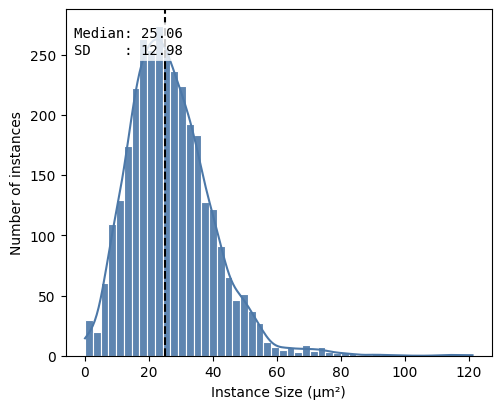

In [21]:
# Calculate segmentation summary statistics for InstanSeg nucleus segmentation
microns_per_pixel = 0.17

df = hp.qc.segmentation_coverage(
    sdata,
    labels_name="labels_nuclei_instanseg",
    microns_per_pixel=microns_per_pixel,
)
display(df)

# Plot histogram of area of segmentation objects for InstanSeg nucleus segmentation
hp.qc.segmentation_histogram(
    sdata,
    labels_name="labels_nuclei_instanseg",
    microns_per_pixel=microns_per_pixel,
    bins=50,
)

### 3.3 Cell segmentation

In [22]:
# Cell segmentation with InstanSeg
import torch
from dask.distributed import LocalCluster, Client

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Using device: {device}.")

cluster = LocalCluster(
    n_workers=8
    if device == "cpu"
    else 1,  # if cuda device available, it is better to increase chunk size to maximal value that fits on the gpu, and set n_workers to 1.
    threads_per_worker=1,
    memory_limit="32GB",
)

client = Client(cluster)

print(client.dashboard_link)

print("Segmenting nuclei:")

sdata = hp.im.segment(
    sdata,
    image_name="REAscreen_IO_CRC_segmentation_channels_clahe",
    output_labels_name=["labels_cells_instanseg"],
    output_shapes_name=["shapes_cells_instanseg"],
    labels_layer_align=None,
    model=hp.im.instanseg_callable,
    # parameters passed to hp.im.instanseg_callable
    output="cells",
    device=device,
    instanseg_model=path_model,
    pixel_size=0.17,
    overwrite=True,
)

client.close()

Using device: mps.


/Users/arne.defauw/VIB/targeted_transcriptomics_training/.venv/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 58916 instead
  warnings.warn(
2026-06-10 14:19:54.724 | INFO     | harpy.image.segmentation._segmentation:_precondition:434 - Provided array is chunked in 'z' and/or 'c' dimension. Will rechunk in 'z' and/or 'c' dimension.


http://127.0.0.1:58916/status
Segmenting nuclei:


/Users/arne.defauw/VIB/targeted_transcriptomics_training/.venv/lib/python3.12/site-packages/harpy/image/segmentation/segmentation_models/_instanseg.py:78: UserWarning: 'torch.load' received a zip file that looks like a TorchScript archive dispatching to 'torch.jit.load' (call 'torch.jit.load' directly to silence this warning)
  instanseg_model = torch.load(instanseg_model, weights_only=False)
/Users/arne.defauw/VIB/targeted_transcriptomics_training/.venv/lib/python3.12/site-packages/instanseg/inference_class.py:473: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with torch.amp.autocast('cuda'):
/Users/arne.defauw/VIB/targeted_transcriptomics_training/.venv/lib/python3.12/site-packages/torch/nn/modules/module.py:1789: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /Users/runner/work/

,labels_name,total_instances,total_area_μm²,covered_area_μm²,covered_area_percentage
0,labels_cells_instanseg,3233,260100.0,126715.7492,48.718089


2026-06-10 14:20:09.574 | INFO     | harpy.qc._qc_segmentation:segmentation_histogram:162 - Calculating cell size for labels element 'labels_cells_instanseg'.
2026-06-10 14:20:09.697 | INFO     | harpy.qc._qc_segmentation:segmentation_histogram:166 - Converting cell area from pixels to square microns using microns_per_pixel=0.17.


<Axes: xlabel='Instance Size (μm²)', ylabel='Number of instances'>

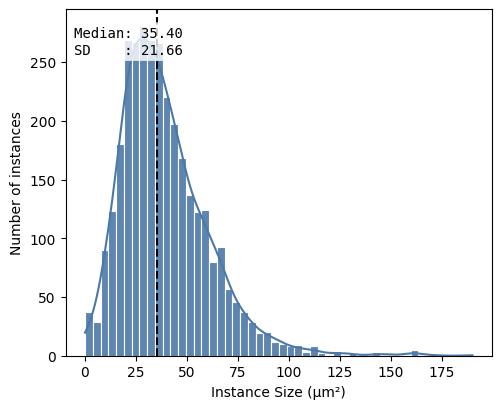

In [23]:
# Calculate segmentation summary statistics for InstanSeg cell segmentation
df = hp.qc.segmentation_coverage(
    sdata,
    labels_name="labels_cells_instanseg",
    microns_per_pixel=microns_per_pixel,
)
display(df)

# Plot histogram of area of segmentation objects for InstanSeg cell segmentation
hp.qc.segmentation_histogram(
    sdata,
    labels_name="labels_cells_instanseg",
    microns_per_pixel=microns_per_pixel,
    bins=50,
)

### 3.4 QC segmentation

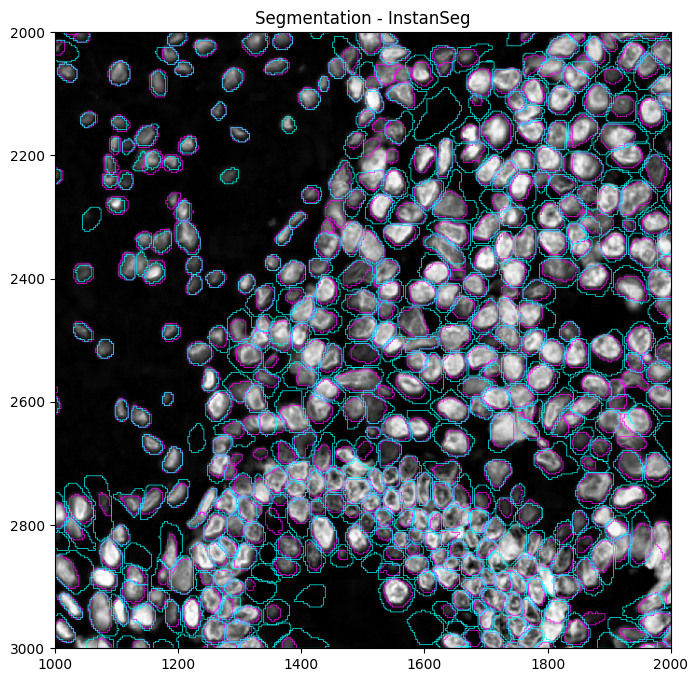

In [24]:
# Plot segmentation results from InstanSeg
min_x = 1000
max_x = 2000
min_y = 2000
max_y = 3000

sdata_crop = sdata.query.bounding_box(
    min_coordinate=[min_x, min_y],
    max_coordinate=[max_x, max_y],
    axes=("x", "y"),
    target_coordinate_system="global_1",
)

fig, ax = plt.subplots(figsize=(8, 8))

sdata_crop.pl.render_images(
    element="REAscreen_IO_CRC_segmentation_channels_clahe", cmap="gray", channel="DAPI"
).pl.render_shapes(
    element="shapes_nuclei_instanseg",
    fill_alpha=0,
    outline_width=0.5,
    outline_alpha=1,
    outline_color="magenta",
).pl.render_shapes(
    element="shapes_cells_instanseg",
    fill_alpha=0,
    outline_width=0.5,
    outline_alpha=1,
    outline_color="cyan",
).pl.show(
    title="Segmentation - InstanSeg",
    coordinate_systems="global_1",
    colorbar=False,
    ax=ax,
)

ax.set_xlim(min_x, max_x)
ax.set_ylim(min_y, max_y)
ax.invert_yaxis()

In [25]:
# Since there are many segmentation channels, it can be helpful to interactively inspect the results in Napari
# from napari_harpy import Interactive

# Interactive(sdata, widgets="viewer")

### 3.4 Align nucleus and cell segmentations

In [26]:
# Align the nucleus and cell segmentations.
sdata = hp.im.align_labels(
    sdata,
    labels_name_1="labels_nuclei_instanseg",
    labels_name_2="labels_cells_instanseg",
    output_labels_name="labels_nuclei_instanseg_aligned",
    output_shapes_name="shapes_nuclei_instanseg_aligned",
    # chunks=2048,
    overwrite=True,
)
# This function aligns two label layers by examining the labels in labels_layer_1 and identifying their maximum overlap with labels in labels_layer_2.
# It then updates the labels of labels_layer_1 (i.e. "labels_nuclei_instanseg").
# If a label from labels_layer_1 has no overlap with a label from label_layer_2, the label in labels_layer_1 is set to zero (i.e. background).
# If two labels from labels_layer_1 overlap with the same label from labels_layer_2, they are effectively merged into the same new label.

2026-06-10 14:20:29.604 | INFO     | harpy.image.segmentation._map:_combine_dask_arrays:339 - Linking labels across chunks.
2026-06-10 14:20:29.619 | INFO     | harpy.image._manager:add_element:47 - Writing results to element 'labels_nuclei_instanseg_aligned'
no parent found for <ome_zarr.reader.Label object at 0x36f2d04a0>: None
no parent found for <ome_zarr.reader.Label object at 0x3881113d0>: None
no parent found for <ome_zarr.reader.Label object at 0x36eac37d0>: None
2026-06-10 14:20:30.010 | INFO     | harpy.shape._manager:_mask_to_polygons_rasterio:338 - Finished vectorizing. Dissolving shapes at the border of the chunks. This can take a couple minutes if input mask contains many chunks.
2026-06-10 14:20:30.056 | INFO     | harpy.shape._manager:_mask_to_polygons_rasterio:344 - Dissolve is done.


2026-06-10 14:20:30.255 | INFO     | harpy.plot._sanity:sanity:269 - Selecting boundaries
2026-06-10 14:20:30.260 | INFO     | harpy.plot._sanity:sanity:306 - Plotting boundaries
2026-06-10 14:20:30.283 | INFO     | harpy.plot._sanity:sanity:314 - End plotting boundaries


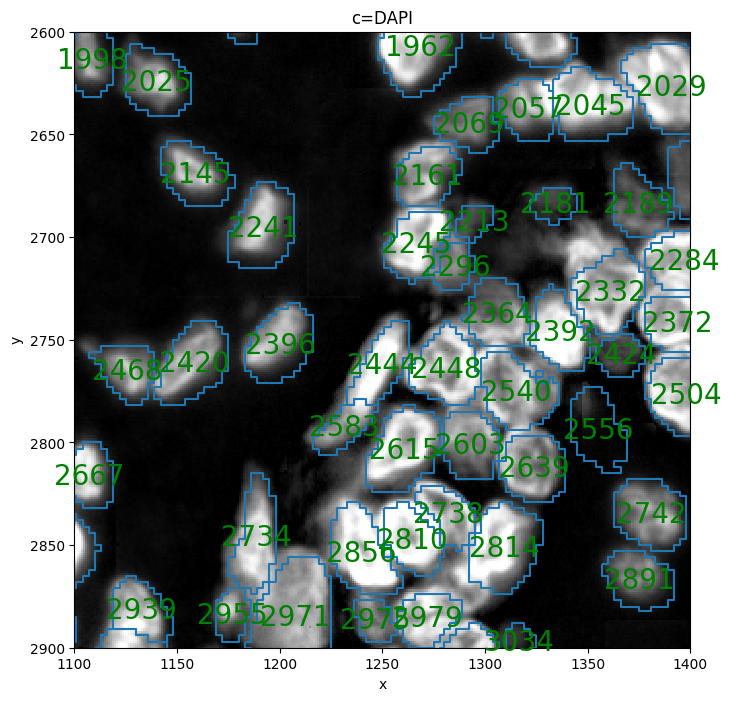

2026-06-10 14:20:30.382 | INFO     | harpy.plot._sanity:sanity:269 - Selecting boundaries
2026-06-10 14:20:30.384 | INFO     | harpy.plot._sanity:sanity:306 - Plotting boundaries
2026-06-10 14:20:30.408 | INFO     | harpy.plot._sanity:sanity:314 - End plotting boundaries


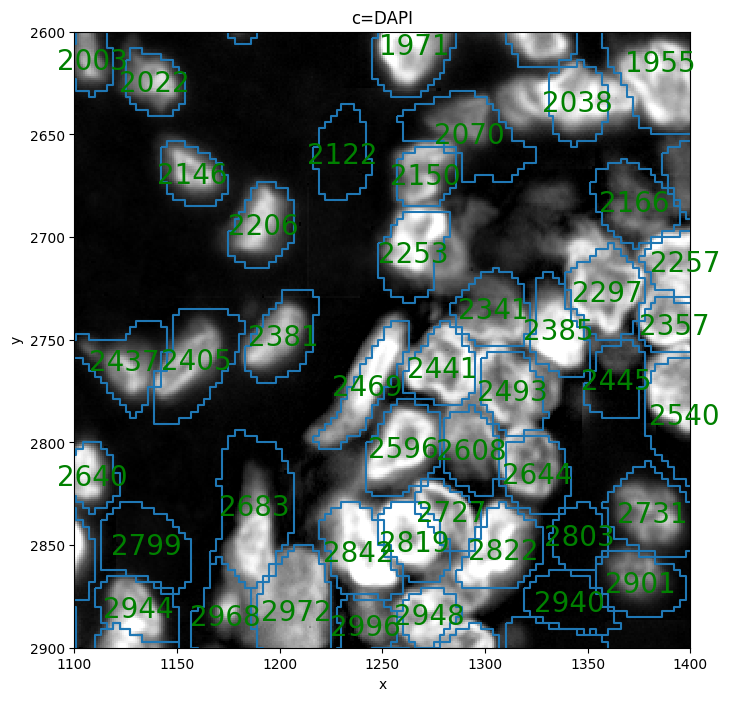

2026-06-10 14:20:30.510 | INFO     | harpy.plot._sanity:sanity:269 - Selecting boundaries
2026-06-10 14:20:30.513 | INFO     | harpy.plot._sanity:sanity:306 - Plotting boundaries
2026-06-10 14:20:30.536 | INFO     | harpy.plot._sanity:sanity:314 - End plotting boundaries


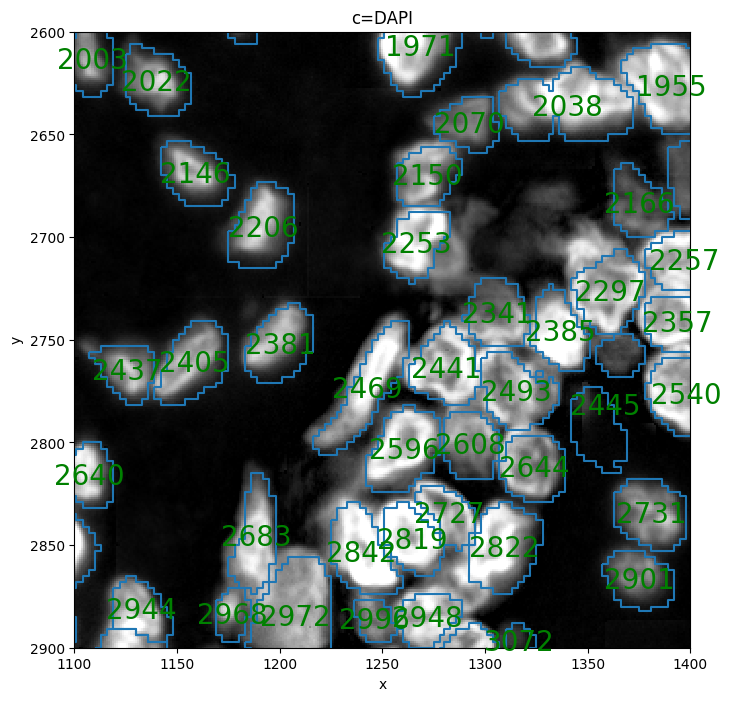

In [27]:
# Sanity check
hp.pl.sanity(
    sdata,
    image_name="REAscreen_IO_CRC_segmentation_channels_clahe",
    channel="DAPI",
    shapes_name="shapes_nuclei_instanseg",
    points_name=None,
    crd=[1100, 1400, 2600, 2900],
    to_coordinate_system="global_1",
    plot_cell_number=True,
    figsize=(8, 8),
)

hp.pl.sanity(
    sdata,
    image_name="REAscreen_IO_CRC_segmentation_channels_clahe",
    channel="DAPI",
    shapes_name="shapes_cells_instanseg",
    points_name=None,
    crd=[1100, 1400, 2600, 2900],
    to_coordinate_system="global_1",
    plot_cell_number=True,
    figsize=(8, 8),
)

hp.pl.sanity(
    sdata,
    image_name="REAscreen_IO_CRC_segmentation_channels_clahe",
    channel="DAPI",
    shapes_name="shapes_nuclei_instanseg_aligned",
    points_name=None,
    crd=[1100, 1400, 2600, 2900],
    to_coordinate_system="global_1",
    plot_cell_number=True,
    figsize=(8, 8),
)


## 4. Cell properties

### 4.1 Cell intensities
Once we have segmentation masks, we can aggregate the intensity values inside those segmentation masks to create an AnnData table. 

We could do this on the raw images, but we can also first normalize the images using quantile normalization. This percentile-based normalization brings the channels onto a comparable image-intensity scale while reducing the influence of a small number of extreme pixels. This is useful for spatial proteomics because different markers can have very different staining intensities, exposure ranges, background levels, and antibody-dependent dynamic ranges. Normalizing each channel before aggregation makes the resulting per-cell mean intensities less dominated by technical scale differences between channels.

In [28]:
# first, we do quantile normalization:
p_min = 0.1
p_max = 99.9

channels = hp.im.get_dataarray(sdata, element_name="REAscreen_IO_CRC").c.data

sdata = hp.im.normalize(
    sdata,
    image_name="REAscreen_IO_CRC",
    output_image_name="REAscreen_IO_CRC_normalized",
    p_min=len(channels) * [p_min],
    p_max=len(channels) * [p_max],
    internal_method="tdigest",
    overwrite=True,
)

2026-06-10 14:20:30.662 | INFO     | harpy.image._map:_precondition:359 - 'combine_z' is False, but not all 'z-slices' spefified in 'fn_kwargs'/'func' ({np.str_('DAPI'): {'p_min': 0.1, 'p_max': 99.9, 'eps': 1e-20, 'internal_method': 'tdigest'}, np.str_('CD279'): {'p_min': 0.1, 'p_max': 99.9, 'eps': 1e-20, 'internal_method': 'tdigest'}, np.str_('Bcl_2'): {'p_min': 0.1, 'p_max': 99.9, 'eps': 1e-20, 'internal_method': 'tdigest'}, np.str_('CD209'): {'p_min': 0.1, 'p_max': 99.9, 'eps': 1e-20, 'internal_method': 'tdigest'}, np.str_('FoxP3'): {'p_min': 0.1, 'p_max': 99.9, 'eps': 1e-20, 'internal_method': 'tdigest'}, np.str_('CD8a'): {'p_min': 0.1, 'p_max': 99.9, 'eps': 1e-20, 'internal_method': 'tdigest'}, np.str_('CD44'): {'p_min': 0.1, 'p_max': 99.9, 'eps': 1e-20, 'internal_method': 'tdigest'}, np.str_('p53'): {'p_min': 0.1, 'p_max': 99.9, 'eps': 1e-20, 'internal_method': 'tdigest'}, np.str_('CD138'): {'p_min': 0.1, 'p_max': 99.9, 'eps': 1e-20, 'internal_method': 'tdigest'}, np.str_('CD45')

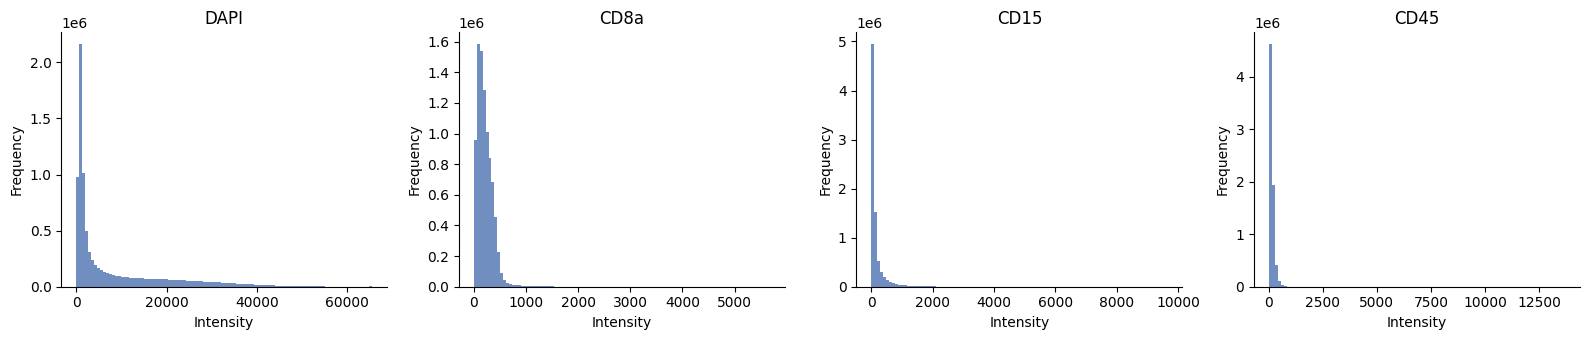

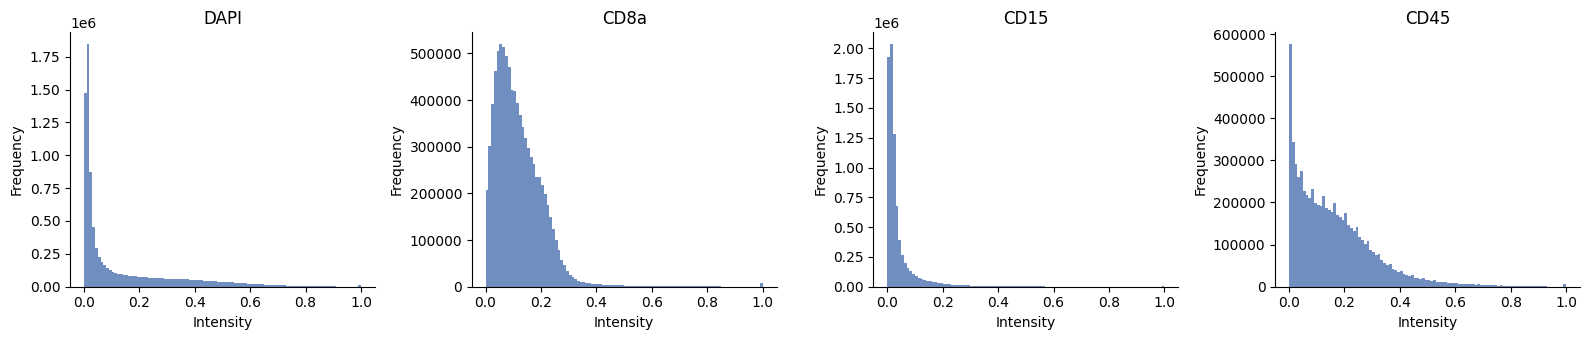

In [29]:
# Plot histogram of pixel intensities for a subset of channels to check the effect of normalization
_channels_to_visualize = [
    "DAPI",
    "CD8a",
    "CD15",
    "CD45",
]

ax = hp.qc.image_histogram(
    sdata,
    image_name="REAscreen_IO_CRC",
    channel=_channels_to_visualize,
    ncols=4,
    bins=100,
)

ax = hp.qc.image_histogram(
    sdata,
    image_name="REAscreen_IO_CRC_normalized",
    channel=_channels_to_visualize,
    ncols=4,
    bins=100,
)

In [30]:
# Calculate intensities for cell segmentations.
sdata = hp.tb.allocate_intensity(
    sdata,
    image_name="REAscreen_IO_CRC_normalized",
    labels_name="labels_cells_instanseg",
    output_table_name="table_cells",
    channels=successful_channels,  # We only want to include the successful channels in the table
    mode="mean",  # When set to "sum", the total intensity for each channel will be added to `.X` of the table layer; if set to `"mean"`, it calculates the average intensity per channel.
    obs_stats=[
        # "sum",
        # "mean",
        # "count",
        "var",
        # "kurtosis",
        # "skew",
        # "max",
        # "min"
    ],  # Stats that will be added to `.obs` of `output_layer`
    chunks=2048,
    to_coordinate_system="global_1",
    overwrite=True,
)

2026-06-10 14:20:54.073 | WARNING  | harpy.utils._aggregate:_center_of_mass:884 - Count was computed for a different index. Recalculating.


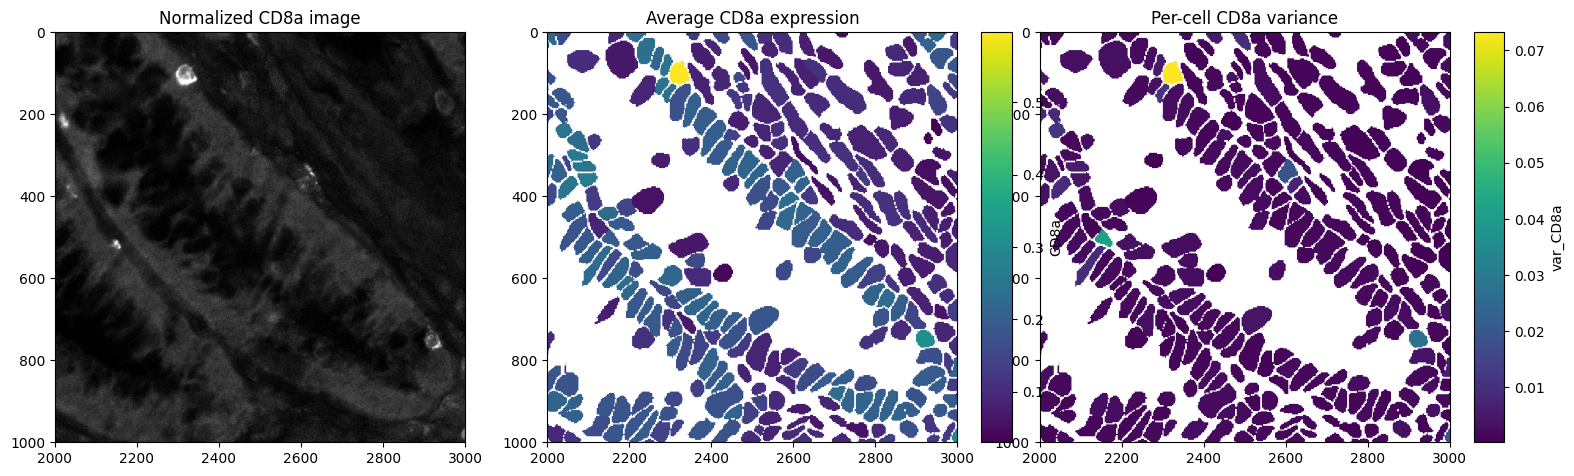

In [31]:
# Plot intensities for CD8a
min_x = 2000
max_x = 3000
min_y = 0
max_y = 1000

sdata_crop = sdata.query.bounding_box(
    min_coordinate=[min_x, min_y],
    max_coordinate=[max_x, max_y],
    axes=("x", "y"),
    target_coordinate_system="global_1",
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Left subplot: Normalized CD8a image
sdata_crop.pl.render_images(
    element="REAscreen_IO_CRC_normalized",
    channel="CD8a",
    cmap="grey",
    colorbar=False,
).pl.show(
    title="Normalized CD8a image",
    coordinate_systems="global_1",
    ax=axes[0],
)

# Middle subplot: Average CD8a expression
sdata_crop.pl.render_labels(
    element="labels_cells_instanseg",
    color="CD8a",
    cmap="viridis",
    fill_alpha=1,
    colorbar=True,
).pl.show(
    title="Average CD8a expression",
    coordinate_systems="global_1",
    ax=axes[1],
)

# Right subplot: CD8a variance
sdata_crop.pl.render_labels(
    element="labels_cells_instanseg",
    color="var_CD8a",
    cmap="viridis",
    fill_alpha=1,
    colorbar=True,
).pl.show(
    title="Per-cell CD8a variance",
    coordinate_systems="global_1",
    ax=axes[2],
)

In [33]:
# Calculate intensities for nucleus segmentations.
sdata = hp.tb.allocate_intensity(
    sdata,
    image_name="REAscreen_IO_CRC_normalized",
    labels_name="labels_nuclei_instanseg_aligned",
    output_table_name="table_nuclei",
    channels=successful_channels,  # We only want to include the successful channels in the table
    mode="mean",  # When set to "sum", the total intensity for each channel will be added to `.X` of the table layer; if set to `"mean"`, it calculates the average intensity per channel.
    obs_stats=None,  # Stats that will be added to `.obs` of `output_layer`
    chunks=2048,
    to_coordinate_system="global_1",
    overwrite=True,
)

# NOTE: It may be more biologically relevant to look at the intensity in the nucleus instead of the entire cell for certain markers. This may, for example, be the case if you know the
# expression is nucleus-bound and you expect the cell segmentation to only add noise to the signal (e.g. because of bleed-through of neighboring cells, background fluorescence, etc.).
# It could also be useful to compare the amount of expression in the nucleus vs. the whole-cell.
# Since the labels are aligned, we could also add these intensities back to the `table_cells` to have everything in one place.

2026-06-10 14:21:45.458 | WARNING  | harpy.utils._aggregate:_center_of_mass:884 - Count was computed for a different index. Recalculating.


### 4.2 Morphological features

#### 4.2.1 Regionprops

In [34]:
# Add morphological properties for cell segmentations.
sdata = hp.tb.add_regionprops(
    sdata,
    labels_name="labels_cells_instanseg",
    table_name="table_cells",
    output_table_name="table_cells",
    properties=[
        "area",
        "eccentricity",
        # "major_axis_length",
        # "minor_axis_length",
        "perimeter",
        # "centroid",
        "convex_area",
        # "equivalent_diameter",
        # "major_minor_axis_ratio",
        # "perim_square_over_area",
        # "major_axis_equiv_diam_ratio",
        # "convex_hull_resid",
        # "centroid_dif",
    ],
    overwrite=True,
)

# area: Area of the segmentation object (in pixels).
# eccentricity: A measure for how much the segmentation object deviates from being circular. Values are between 0-1 (a perfect circle would have value 0).
# major_axis_length: The length of the longest axis of the segmentation object (in pixels).
# minor_axis_length: The length of the shortest axis of the segmentation object (in pixels).
# perimeter: The perimeter of the segmentation object (in pixels).
# centroid_x: x-coordinate of the centroid of the segmentation object (in pixels)
# centroid_y: y-coordinate of the centroid of the segmentation object (in pixels)
# convex_area: Area of the convex hull image, which is the smallest convex polygon that encloses the region (in pixels).
# equivalent_diameter: The diameter of a circle with the same area as the segmentation object (in pixels).
# _major_minor_axis_ratio: The ratio of the major_axis_length over the minor_axis_length.
# _perim_square_over_area: The ratio of the square of the perimeter over the area.
# _major_axis_equiv_diam: major_axis_length / equivalent_diameter.
# _convex_hull_resid: (convex_area - area) / convex_area.
# _centroid_dif: the normalized euclidean distance between the segmentation object centroid and the corresponding convex hull centroid.

2026-06-10 14:21:52.154 | WARNING  | harpy.utils._io:_incremental_io_on_disk:86 - Element with name 'table_cells' already exists. Overwriting...


In [35]:
# Convert values to microns:
microns_per_pixel = 0.17

sdata["table_cells"].obs["area"] = sdata["table_cells"].obs["area"] * microns_per_pixel**2
sdata["table_cells"].obs["perimeter"] = sdata["table_cells"].obs["perimeter"] * microns_per_pixel
sdata["table_cells"].obs["convex_area"] = sdata["table_cells"].obs["convex_area"] * microns_per_pixel**2

region = sdata.tables["table_cells"].uns[TableModel.ATTRS_KEY][TableModel.REGION_KEY]

sdata = hp.tb.add_table(
    sdata,
    adata=sdata.tables["table_cells"],
    output_table_name="table_cells",
    region=region,
    overwrite=True,
)

2026-06-10 14:21:57.830 | WARNING  | harpy.utils._io:_incremental_io_on_disk:86 - Element with name 'table_cells' already exists. Overwriting...


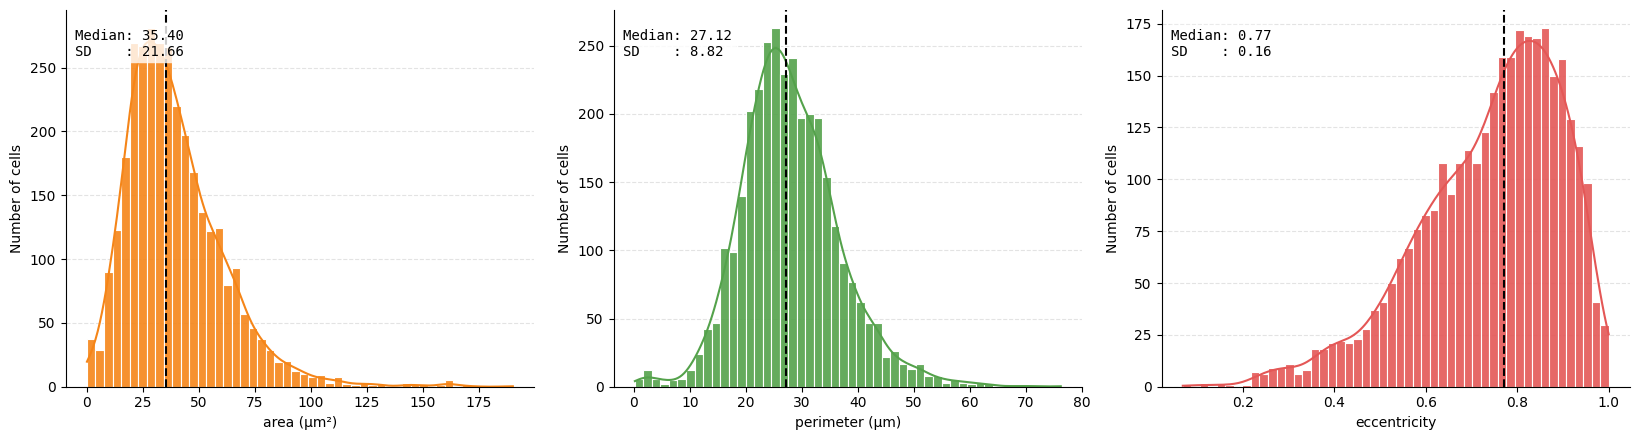

In [36]:
# Plot histogram of regionprops columns
metrics = (
    ("obs", "area"),
    ("obs", "perimeter"),
    ("obs", "eccentricity"),
)

ax = hp.qc.metrics_histogram(
    sdata,
    labels_name="labels_cells_instanseg",
    table_name="table_cells",
    bins=50,
    display_column=["area (μm²)", "perimeter (μm)", "eccentricity"],
    color=[
        "#F58518",
        "#54A24B",
        "#E45756",
    ],
    metrics=metrics,
)

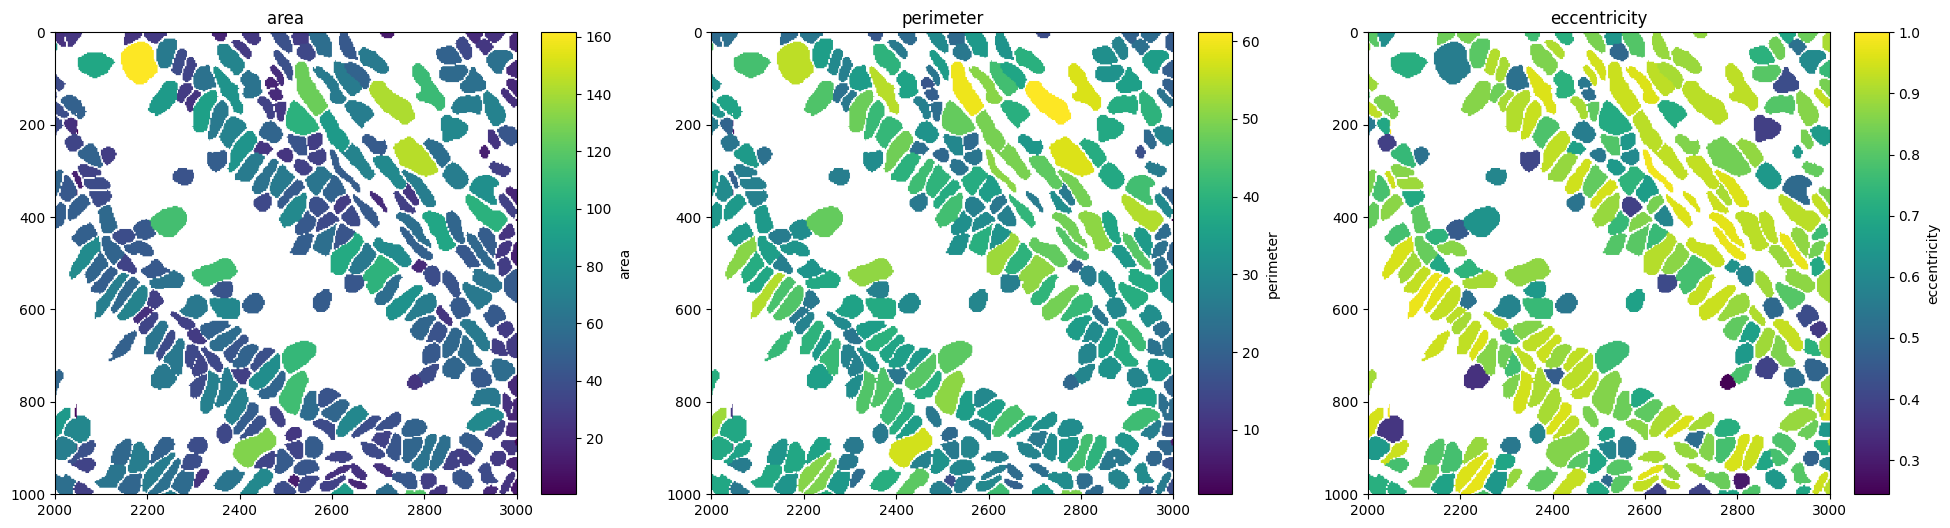

In [37]:
# Plot regionprops columns
min_x = 2000
max_x = 3000
min_y = 0
max_y = 1000

sdata_crop = sdata.query.bounding_box(
    min_coordinate=[min_x, min_y],
    max_coordinate=[max_x, max_y],
    axes=("x", "y"),
    target_coordinate_system="global_1",
)

fig, axes = plt.subplots(1, 3, figsize=(24, 6))

obs_columns = ["area", "perimeter", "eccentricity"]

for ax, column in zip(axes, obs_columns):
    sdata_crop.pl.render_labels(
        element="labels_cells_instanseg",
        color=column,
        cmap="viridis",
        fill_alpha=1,
        colorbar=True,
    ).pl.show(
        title=column,
        coordinate_systems="global_1",
        ax=ax,
    )

#### 4.2.2 Identify cells that contain nuclei

In [38]:
# Determine which cells do not contain a nucleus segmentation
cell_labels_ids = da.unique(sdata["labels_cells_instanseg"].data).compute()
nuclei_labels_ids = da.unique(sdata["labels_nuclei_instanseg_aligned"].data).compute()

cell_without_nucleus_ids = np.setdiff1d(
    cell_labels_ids,
    nuclei_labels_ids,
)

cell_without_nucleus_ids

sdata["table_cells"].obs["contains_nucleus"] = ~sdata["table_cells"].obs["cell_ID"].isin(cell_without_nucleus_ids)
sdata["table_cells"].obs["contains_nucleus"] = sdata["table_cells"].obs["contains_nucleus"].astype("category")

region = sdata.tables["table_cells"].uns[TableModel.ATTRS_KEY][TableModel.REGION_KEY]

sdata = hp.tb.add_table(
    sdata,
    adata=sdata.tables["table_cells"],
    output_table_name="table_cells",
    region=region,
    overwrite=True,
)

2026-06-10 14:22:09.751 | WARNING  | harpy.utils._io:_incremental_io_on_disk:86 - Element with name 'table_cells' already exists. Overwriting...


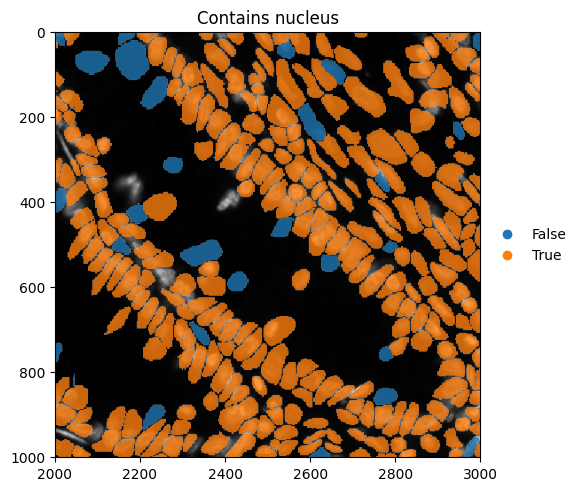

In [39]:
# Plot results
ax = hp.pl.plot_sdata(
    sdata,
    image_name="REAscreen_IO_CRC",
    channel="DAPI",
    labels_name="labels_cells_instanseg",
    table_name="table_cells",
    color="contains_nucleus",
    crd=[2000, 3000, 0, 1000],
    to_coordinate_system="global_1",
    render_images_kwargs={
        "cmap": "gray",
        "scale": "scale1",
    },
    render_labels_kwargs={
        "fill_alpha": 0.8,
    },
    show_kwargs={
        "title": "Contains nucleus",
        "colorbar": False,
    },
)

### 4.3 Filter segmentation masks based on size and artifacts

#### 4.3.1 Identify cells that fall outside size range

In [40]:
# Assign which cells fall outside the appropriate size range
min_area_um2 = 10  # Minimum size of segmentation objects (in square micrometer).
max_area_um2 = 150  # Maximum size of segmentation objects (in square micrometer).

sdata["table_cells"].obs["outside_size_range"] = (
    ~sdata["table_cells"].obs["area"].between(min_area_um2, max_area_um2)
).astype("category")

region = sdata.tables["table_cells"].uns[TableModel.ATTRS_KEY][TableModel.REGION_KEY]

# Add table back to SpatialData object to back to Zarr
sdata = hp.tb.add_table(
    sdata,
    adata=sdata.tables["table_cells"],
    output_table_name="table_cells",
    region=region,
    overwrite=True,
)

2026-06-10 14:22:16.527 | WARNING  | harpy.utils._io:_incremental_io_on_disk:86 - Element with name 'table_cells' already exists. Overwriting...


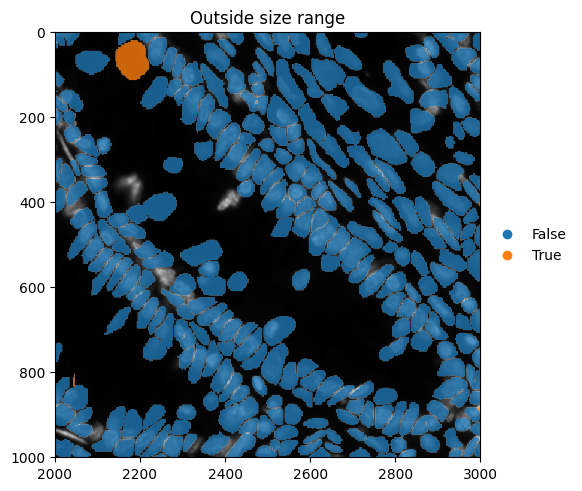

In [41]:
# Plot results
ax = hp.pl.plot_sdata(
    sdata,
    image_name="REAscreen_IO_CRC",
    channel="DAPI",  # or another channel you want as background
    labels_name="labels_cells_instanseg",
    table_name="table_cells",
    color="outside_size_range",
    crd=[2000, 3000, 0, 1000],
    to_coordinate_system="global_1",
    render_images_kwargs={
        "cmap": "gray",
        "scale": "scale1",
    },
    render_labels_kwargs={
        "fill_alpha": 0.8,
    },
    show_kwargs={
        "title": "Outside size range",
        "colorbar": False,
    },
)

#### 4.3.2 Identify cells that occur in artifacts annotations

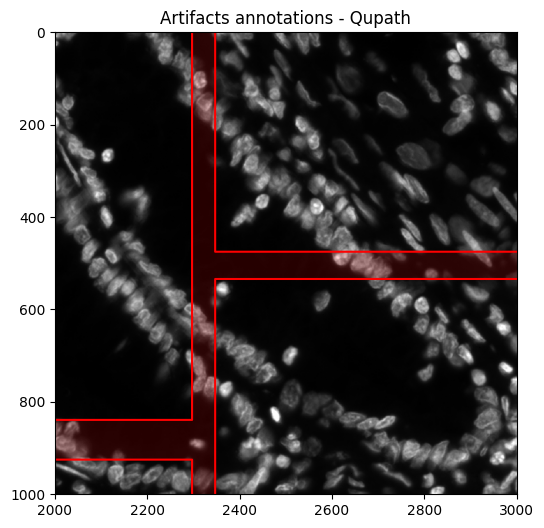

In [42]:
# Let's inspect the artifacts region annotation
from shapely.affinity import translate

min_x = 2000
max_x = 3000
min_y = 0
max_y = 1000

sdata_crop = sdata.query.bounding_box(
    min_coordinate=[min_x, min_y],
    max_coordinate=[max_x, max_y],
    axes=("x", "y"),
    target_coordinate_system="global_1",
)

fig, ax = plt.subplots(figsize=(6, 6))

sdata_crop.pl.render_images(element="REAscreen_IO_CRC", channel="DAPI", cmap="grey").pl.render_shapes(
    element="artifacts", color="red", fill_alpha=0.15, outline_alpha=1, outline_color="red"
).pl.show(
    coordinate_systems="global_1",
    title="Artifacts annotations - Qupath",
    colorbar=False,
    ax=ax,
)

ax.set_xlim(min_x, max_x)
ax.set_ylim(min_y, max_y)
ax.invert_yaxis()

In [43]:
# Assign which cells occur in artifacts
import pandas as pd
import geopandas as gpd


# Get spatial coordinates
spatial_coords = sdata.tables["table_cells"].obsm["spatial"]
spatial_coords_df = pd.DataFrame(
    spatial_coords,
    columns=["x", "y"],
    index=sdata.tables["table_cells"].obs.index,
)

# Build points GeoDataFrame from centroids
points = gpd.GeoDataFrame(
    spatial_coords_df.copy(),
    geometry=gpd.points_from_xy(spatial_coords_df["x"], spatial_coords_df["y"]),
)

# If artifacts annotation has multiple polygons, combine once
artifacts_union = sdata.shapes["artifacts"].geometry.union_all()

# Apply translation (necessary because we are working on a crop of the data of which the origin was reset to (0,0))
tx, ty = get_transformation(sdata.shapes["artifacts"], get_all=True)["global_1"].translation
artifacts_union = translate(artifacts_union, xoff=tx, yoff=ty)

# Create column in table indicating whether each cell is located in an artifact region
in_artifacts_mask = points.geometry.within(artifacts_union)
sdata.tables["table_cells"].obs["in_artifacts"] = pd.Series(
    in_artifacts_mask.values,
    index=sdata.tables["table_cells"].obs.index,
    dtype="boolean",
).astype("category")

region = sdata.tables["table_cells"].uns[TableModel.ATTRS_KEY][TableModel.REGION_KEY]

sdata = hp.tb.add_table(
    sdata,
    adata=sdata.tables["table_cells"],
    output_table_name="table_cells",
    region=region,
    overwrite=True,
)

2026-06-10 14:22:28.969 | WARNING  | harpy.utils._io:_incremental_io_on_disk:86 - Element with name 'table_cells' already exists. Overwriting...


<Axes: title={'center': 'Inside artifact annotation'}>

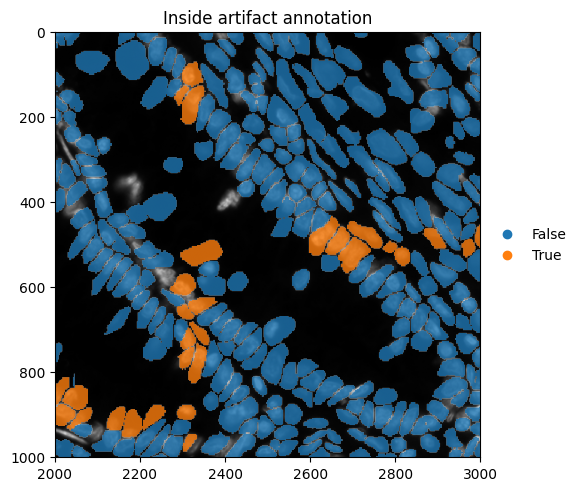

In [44]:
# Plot results
hp.pl.plot_sdata(
    sdata,
    image_name="REAscreen_IO_CRC",
    channel="DAPI",  # or another channel you want as background
    labels_name="labels_cells_instanseg",
    table_name="table_cells",
    color="in_artifacts",
    crd=[2000, 3000, 0, 1000],
    to_coordinate_system="global_1",
    render_images_kwargs={
        "cmap": "gray",
        "scale": "scale1",
    },
    render_labels_kwargs={
        "fill_alpha": 0.8,
    },
    show_kwargs={
        "title": "Inside artifact annotation",
        "colorbar": False,
    },
)

#### 4.3.3 Filter cells

In [45]:
adata = sdata.tables["table_cells"]
mask = adata.obs["outside_size_range"].eq(False) & adata.obs["in_artifacts"].eq(False)
adata_filtered = adata[mask].copy()

region = sdata.tables["table_cells"].uns[TableModel.ATTRS_KEY][TableModel.REGION_KEY]

sdata = hp.tb.add_table(
    sdata,
    adata=adata_filtered,
    output_table_name="table_cells_filtered",
    region=region,
    overwrite=True,
)

### 4.4 Leiden clustering

We can now try to run Leiden clustering to whether we get good cell type annotation.

First, we preprocess the intensity values using 'hp.tb.preprocess_proteomics'. Here, we disable size normalization, library normalization, and log transformation because the table contains mean intensities from already normalized images rather than raw molecule counts. The scaling step z-scores each protein channel across cells, so each marker is centered and put on unit variance. This is a sensible preprocessing step before downstream analyses such as clustering, visualization, or marker comparison, because it prevents high-dynamic-range channels from dominating the analysis while preserving relative differences between cells for each marker. The `max_value_scale=5` cap limits the influence of extreme outlier cells after z-scoring.

In [46]:
# Z-scoring before leiden clustering
sdata = hp.tb.preprocess_proteomics(
    sdata,
    labels_name="labels_cells_instanseg",
    table_name="table_cells_filtered",
    output_table_name="table_cells_filtered_z_scored",
    calculate_cell_size=False,
    size_norm=False,
    library_norm=False,
    log1p=False,
    scale=True,
    max_value_scale=5,
    q=None,
    calculate_pca=False,
    raw_counts_key="mean_counts",
    overwrite=True,
)

2026-06-10 14:22:47.070 | INFO     | harpy.table._preprocess:preprocess:338 - Saving non preprocessed data matrix to the AnnData '.layers[mean_counts]'.


2026-06-10 14:23:14.120 | WARNING  | harpy.utils._io:_incremental_io_on_disk:86 - Element with name 'table_cells_filtered_z_scored' already exists. Overwriting...


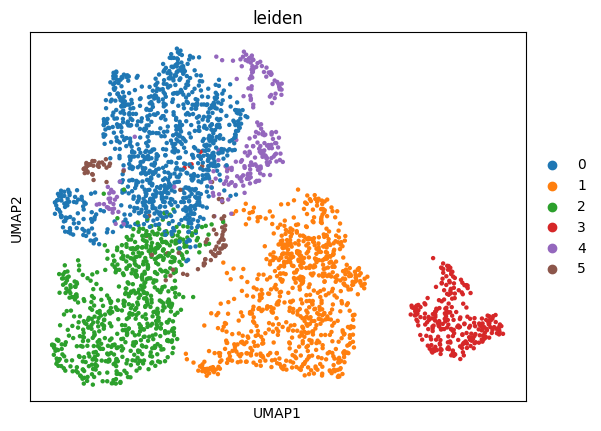

In [47]:
# Leiden clustering
sdata = hp.tb.leiden(
    sdata,
    labels_name="labels_cells_instanseg",
    table_name="table_cells_filtered_z_scored",
    output_table_name="table_cells_filtered_z_scored",
    calculate_umap=True,
    calculate_neighbors=True,
    n_pcs=17,  # The number of principal components to use when calculating neighbors.
    n_neighbors=35,  # The number of neighbors to consider when calculating neighbors.
    resolution=0.4,
    rank_genes=True,
    key_added="leiden",
    overwrite=True,
)

# Plot UMAP
sc.pl.umap(
    sdata.tables["table_cells_filtered_z_scored"],
    color=["leiden"],
    show=True,
)

<Axes: title={'center': 'Leiden clusters'}>

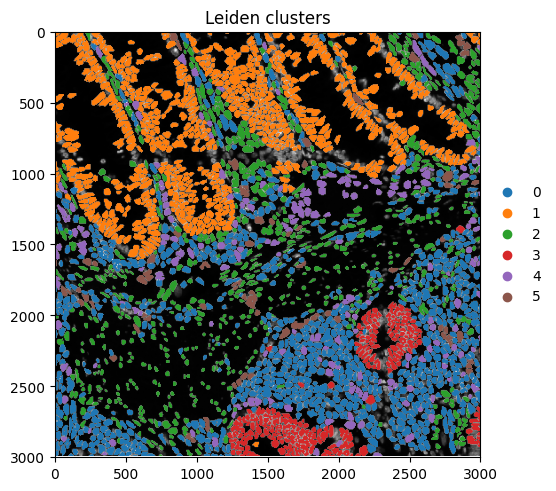

In [48]:
# Plot clusters spatially
hp.pl.plot_sdata(
    sdata,
    image_name="REAscreen_IO_CRC",
    channel="DAPI",
    table_name="table_cells_filtered_z_scored",
    labels_name="labels_cells_instanseg",
    color="leiden",
    to_coordinate_system="global_1",
    render_images_kwargs={"cmap": "grey"},
    render_labels_kwargs={"fill_alpha": 1},
    show_kwargs={"title": "Leiden clusters", "colorbar": False},
)

2026-06-10 14:24:15.607 | INFO     | harpy.table._cluster_intensity:cluster_intensity:80 - Weighted (by instance size) average intensity per cluster (cluster key: 'leiden') will be stored in 'sdata[table_cells_filtered_z_scored].uns[leiden_weighted_intensity]'.
2026-06-10 14:24:15.620 | WARNING  | harpy.table._cluster_intensity:cluster_intensity:94 - Key 'leiden_weighted_intensity' found in sdata[table_cells_filtered_z_scored].uns. Object at that location will be removed and recalculated.
2026-06-10 14:24:19.690 | WARNING  | harpy.utils._io:_incremental_io_on_disk:86 - Element with name 'table_cells_filtered_z_scored' already exists. Overwriting...


,leiden,DAPI,Bcl_2,CD8a,FoxP3,CD138,CD15,CD45,Collagen_I,CD274,...,CD204,MART_1,Melanocyte_PMEL,Cytokeratin_19,Cytokeratin,HLA_DR,beta_Catenin,beta_Actin,CD326,Calponin
0,0,0.240771,0.232132,0.153779,0.261584,0.171825,0.019238,0.208804,0.025729,0.199481,...,0.125306,0.363724,0.326320,0.028976,0.003193,0.082845,0.131608,0.109791,0.019286,0.082830
1,1,0.232336,0.254829,0.177143,0.327191,0.290487,0.095529,0.170571,0.007755,0.208345,...,0.238202,0.488336,0.409858,0.091774,0.094402,0.021514,0.233027,0.062144,0.270042,0.093463
2,2,0.207035,0.181075,0.091838,0.150441,0.130352,0.016183,0.063510,0.017267,0.098859,...,0.041116,0.219927,0.215366,0.022059,0.003193,0.028516,0.114455,0.042416,0.022597,0.135360
3,3,0.307082,0.225257,0.212323,0.385557,0.206920,0.022978,0.205686,0.010673,0.260096,...,0.159706,0.574293,0.471211,0.091757,0.182939,0.267336,0.305215,0.074164,0.121341,0.123560
4,4,0.225643,0.323547,0.181231,0.360170,0.207978,0.131325,0.310822,0.025255,0.238775,...,0.184117,0.407416,0.447775,0.041907,0.008998,0.047242,0.194320,0.166917,0.029849,0.065805
5,5,0.166362,0.210378,0.109076,0.213585,0.147788,0.022251,0.145584,0.034756,0.162847,...,0.102496,0.284816,0.277656,0.027908,0.002772,0.047649,0.120125,0.067198,0.019046,0.063429


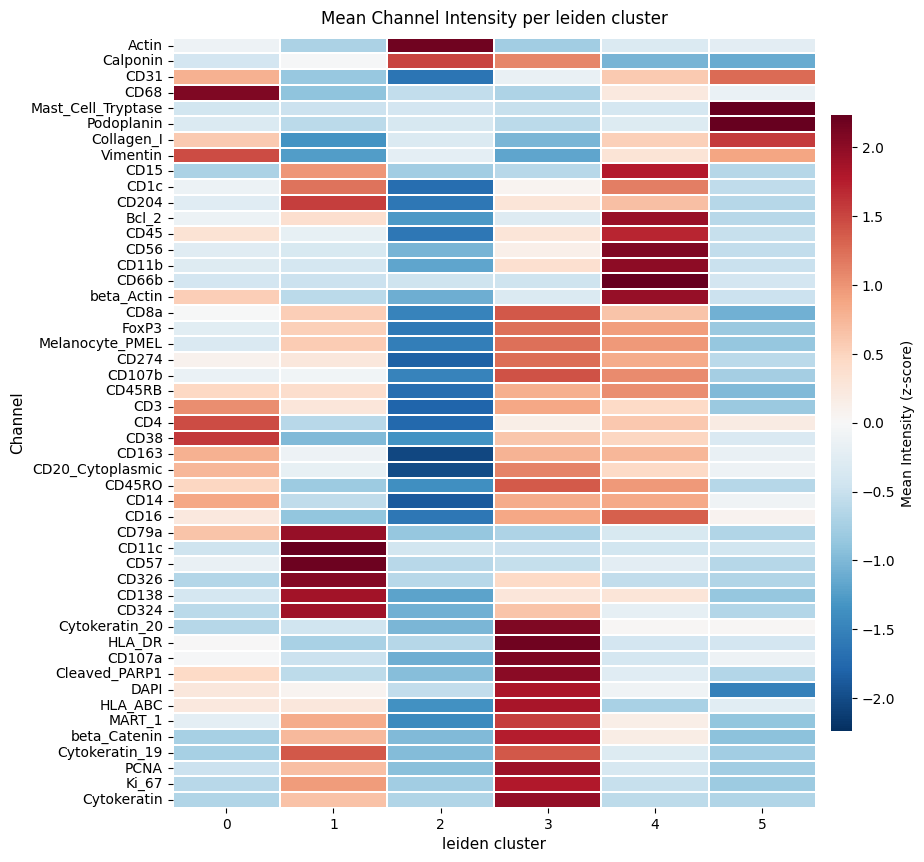

In [53]:
# calculate the mean itensity per leiden cluster
cluster_key = "leiden"

sdata = hp.tb.cluster_intensity(
    sdata,
    table_name="table_cells_filtered_z_scored",
    labels_name="labels_cells_instanseg",
    output_table_name="table_cells_filtered_z_scored",
    cluster_key="leiden",
    layer_mean_intensities="mean_counts",
    cluster_key_uns=f"{cluster_key}_weighted_intensity",
    overwrite=True,
)

display(sdata["table_cells_filtered_z_scored"].uns[f"{cluster_key}_weighted_intensity"])

ax = hp.pl.cluster_intensity_heatmap(
    sdata,
    table_name="table_cells_filtered_z_scored",
    cluster_key="leiden",
    z_score=True,
    figsize=(10, 10),
)

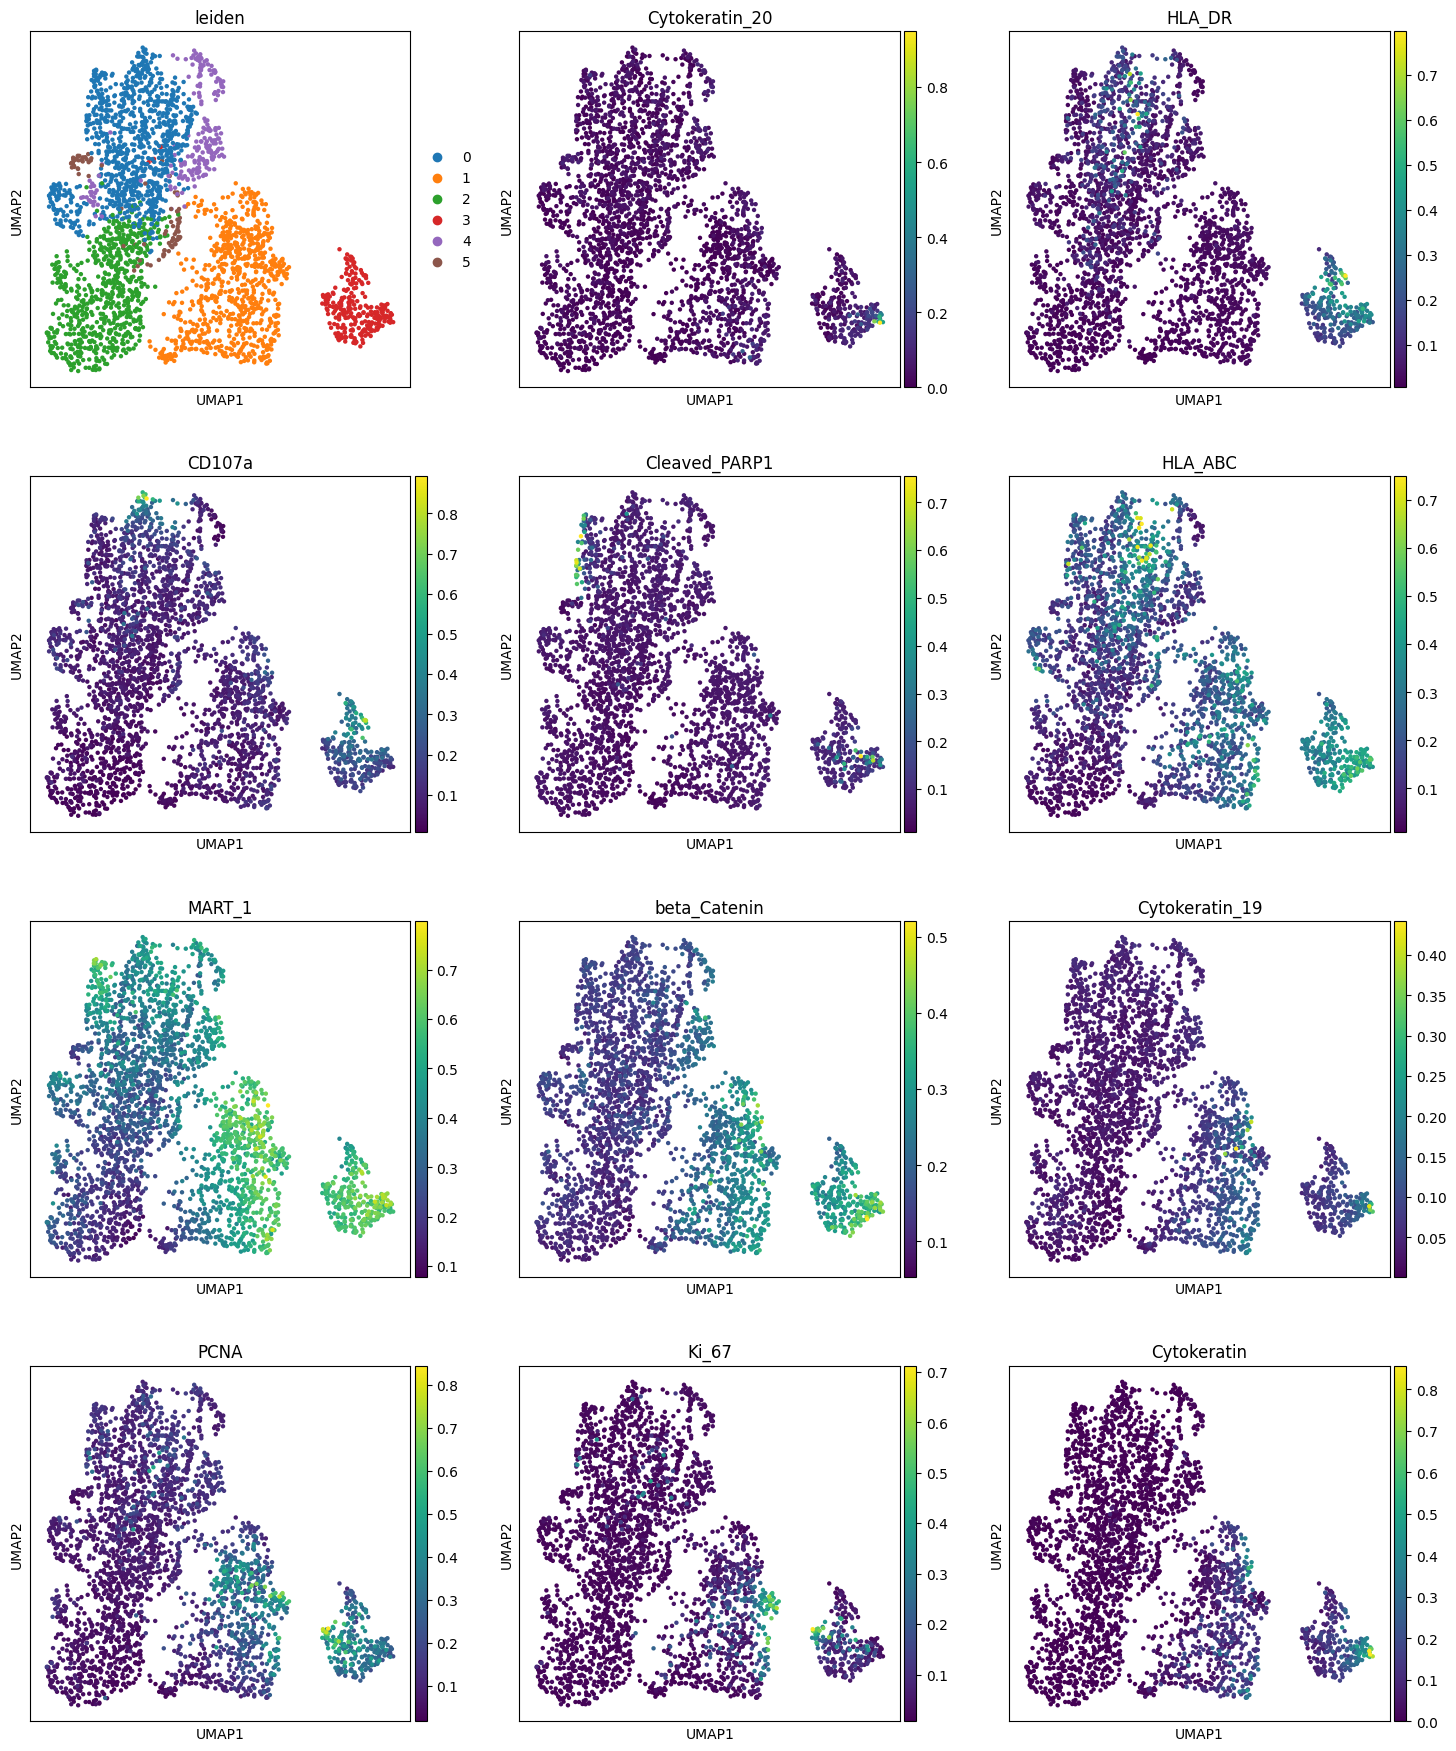

In [50]:
# Let's inspect the most highly expressed markers in cluster 3
from matplotlib.pyplot import rc_context

color_vars = [
    "leiden",
    "Cytokeratin_20",
    "HLA_DR",
    "CD107a",
    "Cleaved_PARP1",
    "HLA_ABC",
    "MART_1",
    "beta_Catenin",
    "Cytokeratin_19",
    "PCNA",
    "Ki_67",
    "Cytokeratin",
]
with rc_context({"figure.figsize": (5, 5)}):
    sc.pl.umap(sdata.tables["table_cells_filtered_z_scored"], color=color_vars, ncols=3)

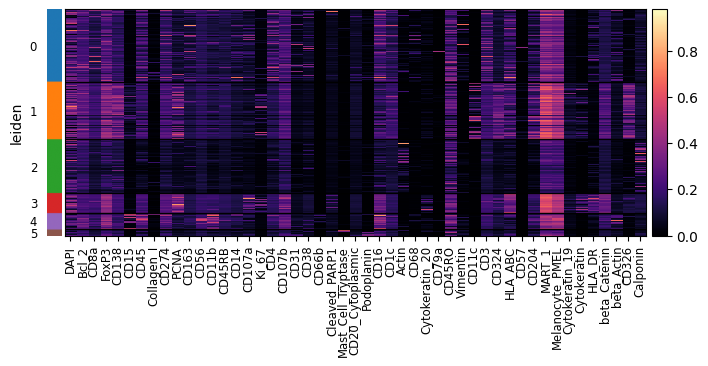

In [51]:
# Plot heatmap
sc.pl.heatmap(
    sdata["table_cells_filtered_z_scored"],
    var_names=sdata["table_cells_filtered_z_scored"].var_names,
    groupby="leiden",
    swap_axes=False,
    norm=None,
    cmap="magma",
    figsize=(8, 3),
    show_gene_labels=True,
)